<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: Anita Hovsepian  
Github Username: anitahov  
USC ID: 6881664760

> **Note:** Fill in your GitHub username and USC ID before submission.


## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [ ]:
# Core data-science packages used throughout the homework
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Make tables/plots easier to read
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')
sns.set_theme(style='whitegrid')

# Reproducibility for the 70/30 split used later
RANDOM_STATE = 42

# Print statements to confirm that all packages were imported
print("NumPy imported successfully.")
print("Pandas imported successfully.")
print("Matplotlib imported successfully.")
print("Seaborn imported successfully.")
print("Statsmodels imported successfully.")
print("Scikit-learn tools imported successfully.")
print("All required packages were imported successfully.")


NumPy imported successfully.
Pandas imported successfully.
Matplotlib imported successfully.
Seaborn imported successfully.
Statsmodels imported successfully.
Scikit-learn tools imported successfully.
All required packages were imported successfully.


Get the Cycle Power Plant Data Set

In [ ]:
# Upload the CCPP Excel file into the notebook
from google.colab import files

print("Please upload Folds5x2_pp.xlsx")
uploaded = files.upload()

# Read Sheet 1 of the uploaded Excel file
data_path = "Folds5x2_pp.xlsx"
df = pd.read_excel(data_path, sheet_name=0)

# Confirm that the dataset loaded correctly
print("\nDataset imported successfully!")
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst five rows:")
display(df.head())

print("\nColumn names:", list(df.columns))
print("\nMissing values:")
print(df.isna().sum())


Please upload Folds5x2_pp.xlsx


Saving Folds5x2_pp.xlsx to Folds5x2_pp (1).xlsx

Dataset imported successfully!
Dataset shape: (9568, 5)
Number of rows: 9568
Number of columns: 5

First five rows:


,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000



Column names: ['AT', 'V', 'AP', 'RH', 'PE']

Missing values:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


### (b) Exploring the data

#### i. rows and columns

In [ ]:
# Get the number of rows and columns in the dataset
rows, cols = df.shape

print(f"Rows: {rows}")
print(f"Columns: {cols}")

# Explain what the rows and columns represent
print("""
Notes:
- Each row represents one hourly average observation from the power plant.
- The dataset contains 9,568 rows and 5 columns.
- AT = Ambient Temperature.
- V = Exhaust Vacuum.
- AP = Ambient Pressure.
- RH = Relative Humidity.
- PE = Net hourly electrical energy output.
- AT, V, AP, and RH are the predictor (independent) variables.
- PE is the response (dependent) variable.
""")


Rows: 9568
Columns: 5

Notes:
- Each row represents one hourly average observation from the power plant.
- The dataset contains 9,568 rows and 5 columns.
- AT = Ambient Temperature.
- V = Exhaust Vacuum.
- AP = Ambient Pressure.
- RH = Relative Humidity.
- PE = Net hourly electrical energy output.
- AT, V, AP, and RH are the predictor (independent) variables.
- PE is the response (dependent) variable.



#### ii. pairwise scatterplots of all the varianbles

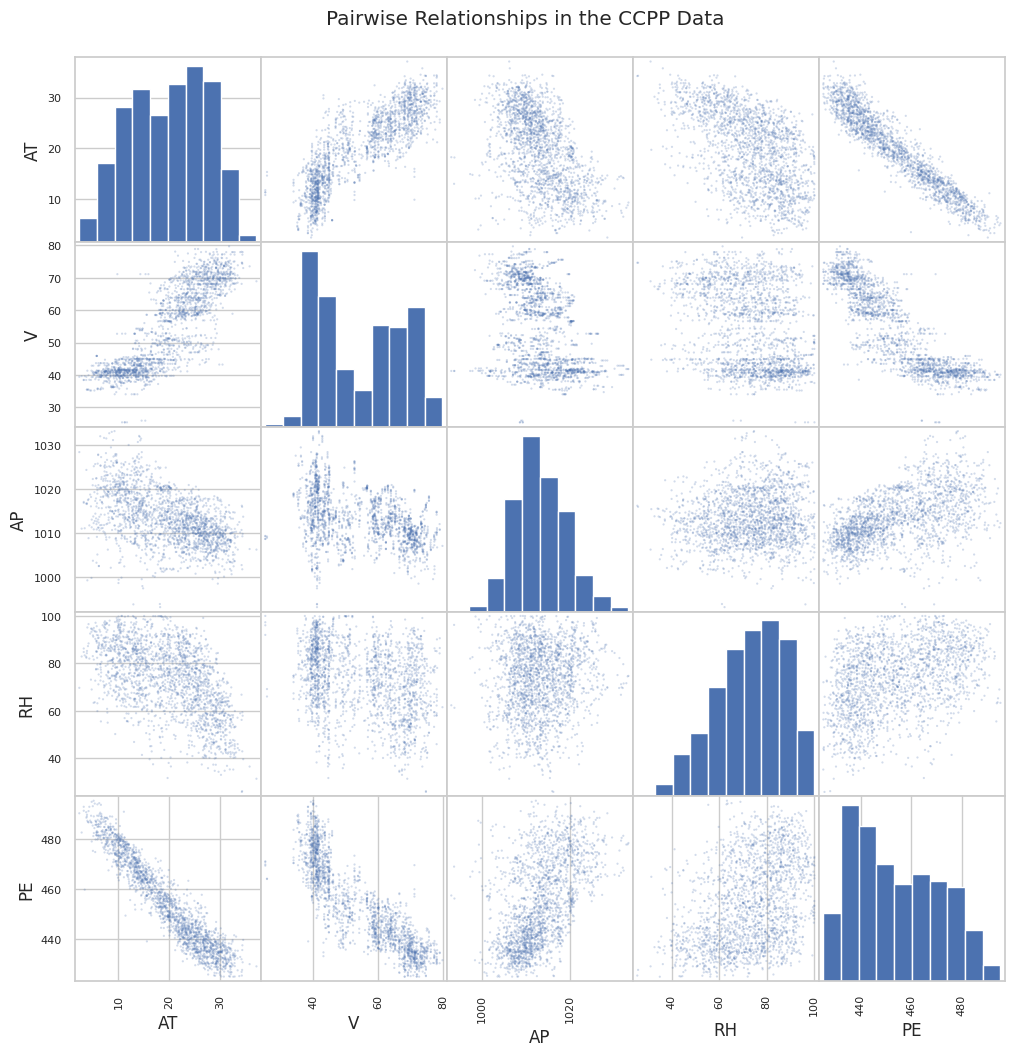

Correlation matrix:


,AT,V,AP,RH,PE
AT,1.0000,0.8440,-0.5080,-0.5430,-0.9480
V,0.8440,1.0000,-0.4140,-0.3120,-0.8700
AP,-0.5080,-0.4140,1.0000,0.1000,0.5180
RH,-0.5430,-0.3120,0.1000,1.0000,0.3900
PE,-0.9480,-0.8700,0.5180,0.3900,1.0000



Findings:
- PE has a strong negative relationship with Ambient Temperature (AT). As temperature increases, power output generally decreases.
- PE also has a strong negative relationship with Exhaust Vacuum (V).
- Ambient Pressure (AP) has a positive relationship with PE.
- Relative Humidity (RH) has a weaker positive relationship with PE.
- AT and V are strongly related to each other, which may affect their coefficients when they are included together in a multiple regression model.
- Some relationships show curvature, which suggests that nonlinear models may be useful later in part (f).



In [ ]:
# Pairwise scatterplots for all variables, including the response.
plot_df = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
pd.plotting.scatter_matrix(plot_df, figsize=(12, 12), diagonal='hist', alpha=0.25, s=10)
plt.suptitle('Pairwise Relationships in the CCPP Data', y=0.92)
plt.show()

# Correlations help summarize the directions seen in the scatterplots.
print('Correlation matrix:')
display(df.corr(numeric_only=True).round(3))

print("""
Findings:
- PE has a strong negative relationship with Ambient Temperature (AT). As temperature increases, power output generally decreases.
- PE also has a strong negative relationship with Exhaust Vacuum (V).
- Ambient Pressure (AP) has a positive relationship with PE.
- Relative Humidity (RH) has a weaker positive relationship with PE.
- AT and V are strongly related to each other, which may affect their coefficients when they are included together in a multiple regression model.
- Some relationships show curvature, which suggests that nonlinear models may be useful later in part (f).
""")


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [ ]:
# Build the requested descriptive-statistics table.
summary = pd.DataFrame(index=df.columns)
summary['mean'] = df.mean()
summary['median'] = df.median()
summary['min'] = df.min()
summary['max'] = df.max()
summary['range'] = df.max() - df.min()
summary['Q1'] = df.quantile(0.25)
summary['Q3'] = df.quantile(0.75)
summary['IQR'] = summary['Q3'] - summary['Q1']

display(summary.round(3))


,mean,median,min,max,range,Q1,Q3,IQR
AT,19.6510,20.3450,1.8100,37.1100,35.3000,13.5100,25.7200,12.2100
V,54.3060,52.0800,25.3600,81.5600,56.2000,41.7400,66.5400,24.8000
AP,1013.2590,1012.9400,992.8900,1033.3000,40.4100,1009.1000,1017.2600,8.1600
RH,73.3090,74.9750,25.5600,100.1600,74.6000,63.3280,84.8300,21.5020
PE,454.3650,451.5500,420.2600,495.7600,75.5000,439.7500,468.4300,28.6800


### (c) Simple Linear Regression

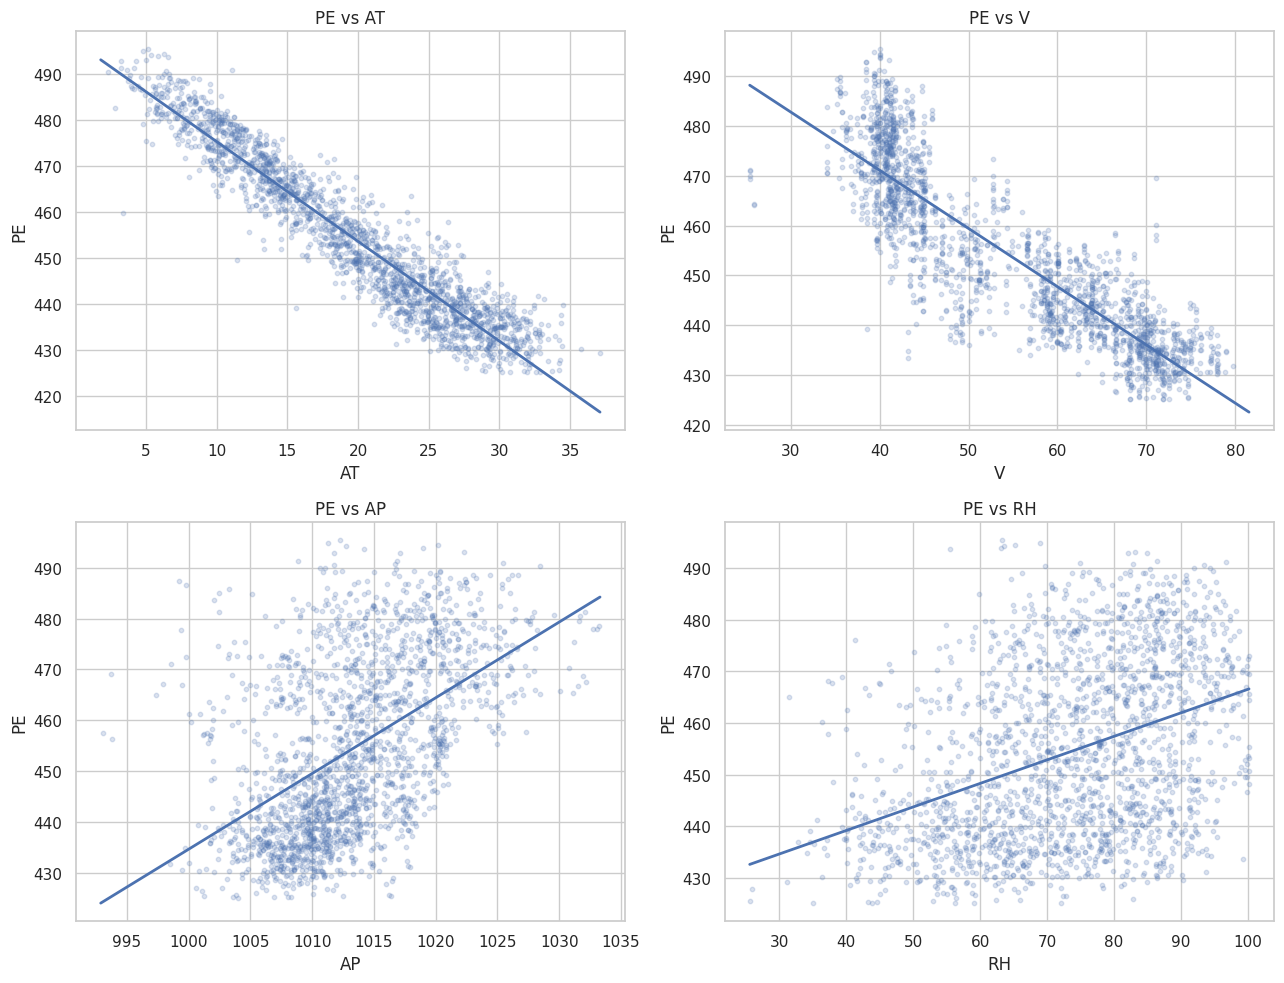

Simple Linear Regression Results:


,Intercept,Coefficient,p-value,R-squared
Predictor,,,,
AT,497.0341,-2.1713,0.0000,0.8989
V,517.8015,-1.1681,0.0000,0.7565
AP,-1055.2610,1.4899,0.0000,0.2688
RH,420.9618,0.4557,0.0000,0.1519



Statistically significant predictors at alpha = 0.05:
['AT', 'V', 'AP', 'RH']

Potential regression outliers:
AT: 42 observations with |studentized residual| > 3
V: 33 observations with |studentized residual| > 3
AP: 29 observations with |studentized residual| > 3
RH: 2 observations with |studentized residual| > 3

Conclusion:
- AT, V, AP, and RH each have a statistically significant association with PE (p < 0.05).
- AT and V have negative relationships with PE.
- AP and RH have positive relationships with PE.
- AT has the highest R-squared among the four simple regression models.
- Some observations may be identified as potential outliers by the regression diagnostics.
- I would not automatically remove these observations because there is no evidence that they are data-entry errors.
- Observations should only be removed after investigating whether they are invalid or excessively influential.



In [ ]:
# Fit one simple linear regression for each predictor
response = 'PE'
predictors = ['AT', 'V', 'AP', 'RH']

simple_models = {}
simple_rows = []

# Create four regression plots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, x in zip(axes, predictors):

    # Fit simple linear regression using ALL observations
    model = smf.ols(f'{response} ~ {x}', data=df).fit()
    simple_models[x] = model

    # Save important regression results
    simple_rows.append({
        'Predictor': x,
        'Intercept': model.params['Intercept'],
        'Coefficient': model.params[x],
        'p-value': model.pvalues[x],
        'R-squared': model.rsquared
    })

    # Use a sample only for plotting so the graph loads faster
    vis = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)

    ax.scatter(vis[x], vis[response], alpha=0.20, s=10)

    # Draw regression line
    xgrid = np.linspace(df[x].min(), df[x].max(), 200)
    ygrid = model.params['Intercept'] + model.params[x] * xgrid
    ax.plot(xgrid, ygrid, linewidth=2)

    ax.set_title(f'{response} vs {x}')
    ax.set_xlabel(x)
    ax.set_ylabel(response)

plt.tight_layout()
plt.show()

# Display regression results
simple_results = pd.DataFrame(simple_rows).set_index('Predictor')

print("Simple Linear Regression Results:")
display(simple_results.round(4))

# Determine which predictors are statistically significant
print("\nStatistically significant predictors at alpha = 0.05:")
significant = simple_results.index[
    simple_results['p-value'] < 0.05
].tolist()

print(significant)


# -------------------------------------------------------
# Check for possible regression outliers
# -------------------------------------------------------

print("\nPotential regression outliers:")

for x in predictors:
    model = simple_models[x]

    # Internally studentized residuals are much faster
    influence = model.get_influence()
    student_resid = influence.resid_studentized_internal

    # Flag observations with absolute residual greater than 3
    outlier_count = np.sum(np.abs(student_resid) > 3)

    print(
        f"{x}: {outlier_count} observations "
        f"with |studentized residual| > 3"
    )


# -------------------------------------------------------
# Final interpretation
# -------------------------------------------------------

print("""
Conclusion:
- AT, V, AP, and RH each have a statistically significant association with PE (p < 0.05).
- AT and V have negative relationships with PE.
- AP and RH have positive relationships with PE.
- AT has the highest R-squared among the four simple regression models.
- Some observations may be identified as potential outliers by the regression diagnostics.
- I would not automatically remove these observations because there is no evidence that they are data-entry errors.
- Observations should only be removed after investigating whether they are invalid or excessively influential.
""")

### (d) Multiple Regression

In [ ]:
# Multiple regression uses all predictors at the same time.
formula_multiple = response + ' ~ ' + ' + '.join(predictors)
multiple_model = smf.ols(formula_multiple, data=df).fit()
print(multiple_model.summary())

coef_table = pd.DataFrame({
    'coefficient': multiple_model.params,
    'p-value': multiple_model.pvalues
})
display(coef_table)

significant_multiple = [x for x in predictors if multiple_model.pvalues[x] < 0.05]
print('Predictors for which H0: beta_j = 0 is rejected at alpha=0.05:')
print(significant_multiple)

print("""
Interpretation:
Each coefficient is the expected change in PE for a one-unit increase in that predictor while holding the other predictors fixed.
A p-value below 0.05 provides evidence that the predictor contributes to the multiple regression after controlling for the others.
""")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:03:17   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

,coefficient,p-value
Intercept,454.6093,0.0000
AT,-1.9775,0.0000
V,-0.2339,0.0000
AP,0.0621,0.0000
RH,-0.1581,0.0000


Predictors for which H0: beta_j = 0 is rejected at alpha=0.05:
['AT', 'V', 'AP', 'RH']

Interpretation:
Each coefficient is the expected change in PE for a one-unit increase in that predictor while holding the other predictors fixed.
A p-value below 0.05 provides evidence that the predictor contributes to the multiple regression after controlling for the others.



### (e) 1c Compare to 1d

,Simple coefficient,Multiple coefficient
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


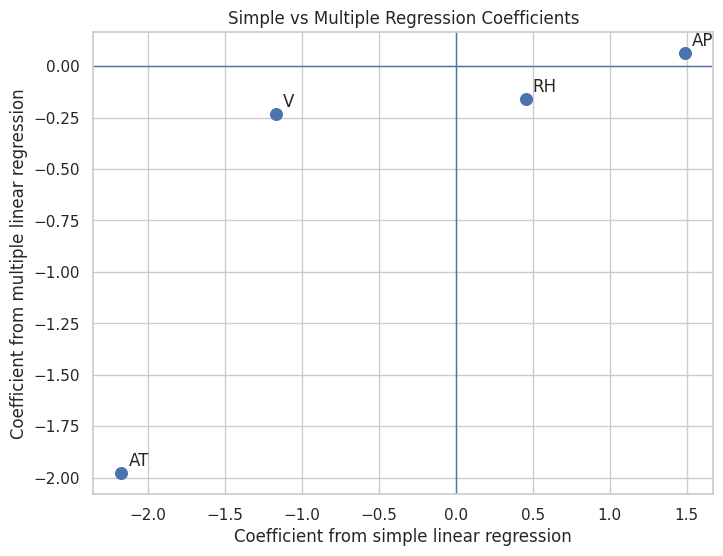


Conclusion:
The coefficients are not identical because the simple models ignore the other predictors, while the multiple model holds them constant.
Differences in size or even direction are possible when predictors are correlated. This is why a variable's simple-regression effect should not automatically be interpreted as its adjusted effect.



In [ ]:
# Compare the coefficient from each simple model with its coefficient in the multiple model.
comparison = pd.DataFrame({
    'Simple coefficient': [simple_models[x].params[x] for x in predictors],
    'Multiple coefficient': [multiple_model.params[x] for x in predictors]
}, index=predictors)
display(comparison)

plt.figure(figsize=(8, 6))
plt.scatter(comparison['Simple coefficient'], comparison['Multiple coefficient'], s=70)
for x in predictors:
    plt.annotate(x, (comparison.loc[x, 'Simple coefficient'], comparison.loc[x, 'Multiple coefficient']),
                 xytext=(5, 5), textcoords='offset points')
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel('Coefficient from simple linear regression')
plt.ylabel('Coefficient from multiple linear regression')
plt.title('Simple vs Multiple Regression Coefficients')
plt.show()

print("""
Conclusion:
The coefficients are not identical because the simple models ignore the other predictors, while the multiple model holds them constant.
Differences in size or even direction are possible when predictors are correlated. This is why a variable's simple-regression effect should not automatically be interpreted as its adjusted effect.
""")


### (f) Nonlinear Association

/tmp/ipykernel_1127/2580664832.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols(formula, data=df).fit()


,linear p,quadratic p,cubic p,R-squared
Predictor,,,,
AT,0.0000,0.0000,0.0000,0.9119
V,0.0000,0.7685,0.0137,0.7750
AP,0.0000,0.0000,0.0000,0.2749
RH,0.0004,0.0000,0.0000,0.1537


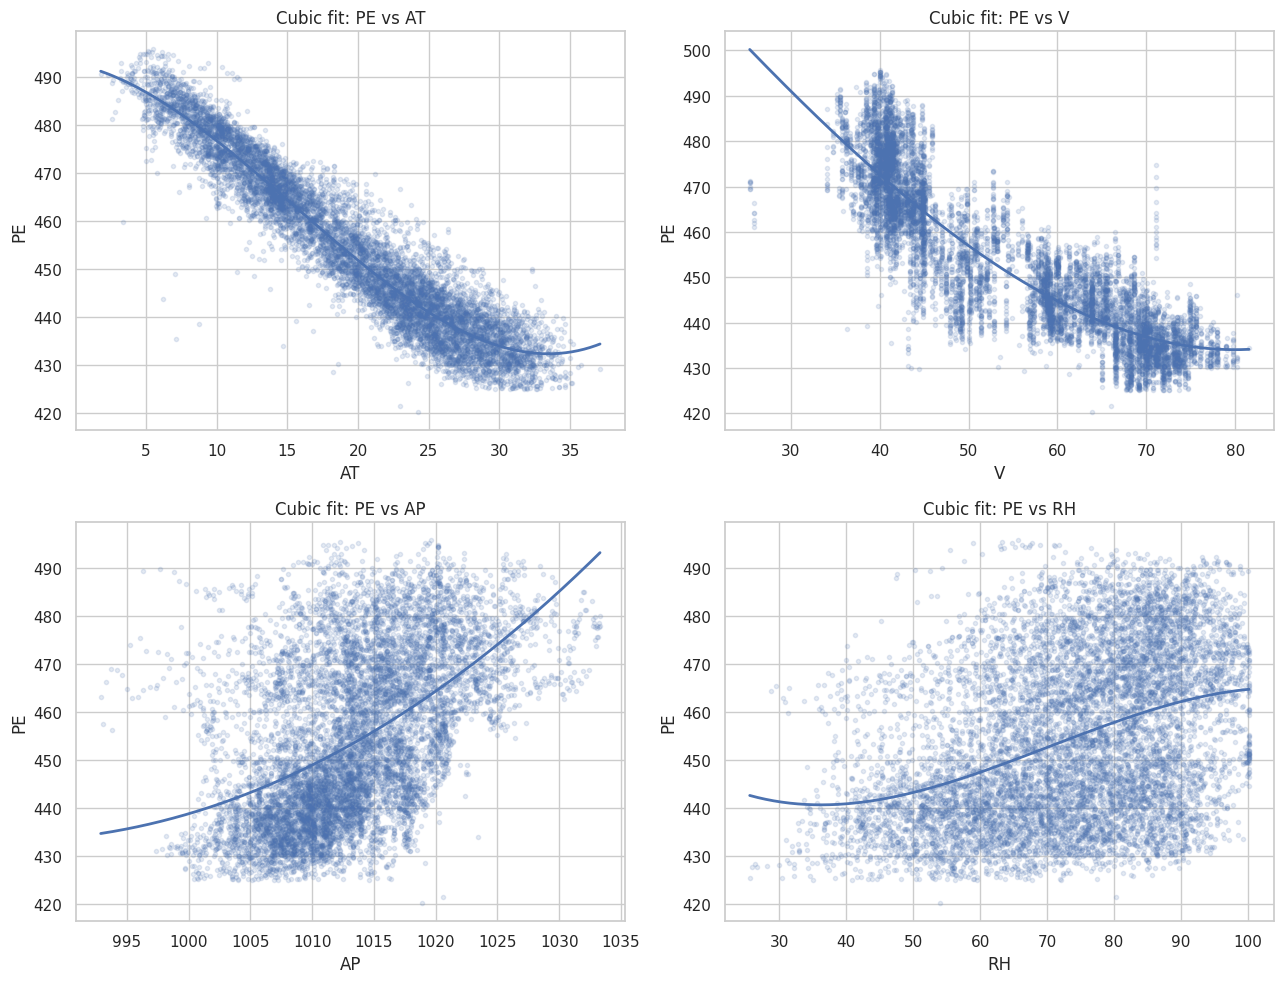

AT: evidence of nonlinearity = True
V: evidence of nonlinearity = True
AP: evidence of nonlinearity = True
RH: evidence of nonlinearity = True

Conclusion:
- There is evidence of nonlinear association between each predictor and PE.
- For AT, V, AP, and RH, at least one higher-order term (quadratic or cubic) is statistically significant at the 0.05 level.
- Therefore, a simple straight-line relationship does not fully describe the association between these predictors and PE.
- The fitted cubic curves also visually show curvature in the relationships.



In [ ]:
# For each predictor fit: PE = b0 + b1*X + b2*X^2 + b3*X^3 + error
poly_rows = []
poly_models = {}

for x in predictors:
    # I(...) tells patsy to treat the expression as arithmetic.
    formula = f'{response} ~ {x} + I({x}**2) + I({x}**3)'
    model = smf.ols(formula, data=df).fit()
    poly_models[x] = model
    poly_rows.append({
        'Predictor': x,
        'linear p': model.pvalues.get(x, np.nan),
        'quadratic p': model.pvalues.get(f'I({x} ** 2)', np.nan),
        'cubic p': model.pvalues.get(f'I({x} ** 3)', np.nan),
        'R-squared': model.rsquared
    })

poly_results = pd.DataFrame(poly_rows).set_index('Predictor')
display(poly_results)

# Plot observed values and the fitted cubic curve for each predictor.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, x in zip(axes, predictors):
    grid = pd.DataFrame({x: np.linspace(df[x].min(), df[x].max(), 250)})
    pred = poly_models[x].predict(grid)
    ax.scatter(df[x], df[response], alpha=0.15, s=9)
    ax.plot(grid[x], pred, linewidth=2)
    ax.set_xlabel(x); ax.set_ylabel(response); ax.set_title(f'Cubic fit: {response} vs {x}')
plt.tight_layout(); plt.show()

for x in predictors:
    q = poly_results.loc[x]
    nonlinear = (q['quadratic p'] < 0.05) or (q['cubic p'] < 0.05)
    print(f'{x}: evidence of nonlinearity = {nonlinear}')

print("""
Conclusion:
- There is evidence of nonlinear association between each predictor and PE.
- For AT, V, AP, and RH, at least one higher-order term (quadratic or cubic) is statistically significant at the 0.05 level.
- Therefore, a simple straight-line relationship does not fully describe the association between these predictors and PE.
- The fitted cubic curves also visually show curvature in the relationships.
""")


### (g) Interactions of Predictors

In [ ]:
# Full model containing all main effects and every pairwise interaction.
interaction_terms = [f'{a}:{b}' for a, b in combinations(predictors, 2)]
formula_interactions = response + ' ~ ' + ' + '.join(predictors + interaction_terms)
interaction_model = smf.ols(formula_interactions, data=df).fit()
print(interaction_model.summary())

interaction_pvalues = interaction_model.pvalues[[t for t in interaction_terms if t in interaction_model.pvalues.index]]
interaction_table = pd.DataFrame({'p-value': interaction_pvalues, 'Significant (p<0.05)': interaction_pvalues < 0.05})
display(interaction_table)

print('Significant interaction terms at alpha=0.05:')
print(list(interaction_table.index[interaction_table['Significant (p<0.05)']]))

print("""
Conclusion:
- Four of the six pairwise interaction terms are statistically significant at alpha = 0.05.
- The significant interactions are AT:V, AT:RH, V:AP, and AP:RH.
- AT:AP and V:RH are not statistically significant at the 0.05 level.
- A significant interaction means that the relationship between one predictor and PE depends on the value of another predictor.
- Therefore, the data provide evidence that several predictors interact with each other when explaining PE.
""")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:05:33   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,p-value,Significant (p<0.05)
AT:V,0.0000,True
AT:AP,0.4521,False
AT:RH,0.0000,True
V:AP,0.0000,True
V:RH,0.0862,False
AP:RH,0.0336,True


Significant interaction terms at alpha=0.05:
['AT:V', 'AT:RH', 'V:AP', 'AP:RH']

Conclusion:
- Four of the six pairwise interaction terms are statistically significant at alpha = 0.05.
- The significant interactions are AT:V, AT:RH, V:AP, and AP:RH.
- AT:AP and V:RH are not statistically significant at the 0.05 level.
- A significant interaction means that the relationship between one predictor and PE depends on the value of another predictor.
- Therefore, the data provide evidence that several predictors interact with each other when explaining PE.



### (h) Improvement

In [ ]:
# Use the SAME 70/30 split for fair model comparison.
train_df, test_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)

# Model 1: ordinary multiple linear regression with all four predictors.
base_model = smf.ols(formula_multiple, data=train_df).fit()
base_train_pred = base_model.predict(train_df)
base_test_pred = base_model.predict(test_df)
base_train_mse = mean_squared_error(train_df[response], base_train_pred)
base_test_mse = mean_squared_error(test_df[response], base_test_pred)

# Model 2 starts with all main effects, all pairwise interactions, and all quadratic terms.
main_terms = predictors.copy()
quad_terms = [f'I({x}**2)' for x in predictors]
inter_terms = [f'{a}:{b}' for a, b in combinations(predictors, 2)]
all_terms = main_terms + quad_terms + inter_terms

# Backward elimination with hierarchy protection:
# - Main effects are always kept.
# - A quadratic or interaction can be removed if its p-value >= 0.05.
# Keeping main effects protects the hierarchy whenever a higher-order term remains.
def backward_hierarchical(data, response, main_terms, higher_terms, alpha=0.05):
    active_higher = higher_terms.copy()
    history = []
    while True:
        terms = main_terms + active_higher
        model = smf.ols(response + ' ~ ' + ' + '.join(terms), data=data).fit()
        # Statsmodels may insert spaces inside I(X ** 2), so match names after removing spaces.
        pmap = {name.replace(' ', ''): p for name, p in model.pvalues.items()}
        candidates = {t: pmap.get(t.replace(' ', ''), 0.0) for t in active_higher}
        if not candidates:
            return model, history
        worst_term, worst_p = max(candidates.items(), key=lambda z: z[1])
        if worst_p < alpha:
            return model, history
        history.append((worst_term, worst_p))
        active_higher.remove(worst_term)

improved_model, elimination_history = backward_hierarchical(
    train_df, response, main_terms, quad_terms + inter_terms, alpha=0.05
)

improved_train_pred = improved_model.predict(train_df)
improved_test_pred = improved_model.predict(test_df)
improved_train_mse = mean_squared_error(train_df[response], improved_train_pred)
improved_test_mse = mean_squared_error(test_df[response], improved_test_pred)

mse_comparison = pd.DataFrame({
    'Model': ['All-predictor linear', 'Selected quadratic + interaction'],
    'Train MSE': [base_train_mse, improved_train_mse],
    'Test MSE': [base_test_mse, improved_test_mse]
}).set_index('Model')
display(mse_comparison)

print('Removed higher-order terms (in order):')
for term, p in elimination_history:
    print(f'  {term}: p={p:.4g}')
print('\nFinal selected model:')
print(improved_model.model.formula)
print('\nFinal coefficient p-values:')
display(pd.DataFrame({'coef': improved_model.params, 'p-value': improved_model.pvalues}))

print("""
Conclusion:
- The selected nonlinear/interaction model improves on the basic multiple linear regression model for this 70/30 split.
- The basic linear model has a test MSE of 21.2399.
- The selected nonlinear/interaction model has a lower test MSE of 18.6600.
- The lower test MSE indicates better prediction on this particular test set.
- Backward elimination removed higher-order terms that were not statistically significant while keeping all main effects to preserve model hierarchy.
- Therefore, adding selected nonlinear and interaction terms provides a meaningful improvement over the basic additive linear model on this split.
""")


,Train MSE,Test MSE
Model,,
All-predictor linear,20.5808,21.2399
Selected quadratic + interaction,17.8908,18.6600


Removed higher-order terms (in order):
  V:RH: p=0.8674
  I(V**2): p=0.6077
  V:AP: p=0.3578

Final selected model:
PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2) + AT:V + AT:AP + AT:RH + AP:RH

Final coefficient p-values:


,coef,p-value
Intercept,-7568.5210,0.0000
AT,-9.6925,0.0000
V,-0.4604,0.0000
AP,15.7203,0.0000
RH,3.7204,0.0001
I(AT ** 2),0.0195,0.0000
I(AP ** 2),-0.0076,0.0000
I(RH ** 2),-0.0019,0.0000
AT:V,0.0082,0.0000
AT:AP,0.0070,0.0015



Conclusion:
- The selected nonlinear/interaction model improves on the basic multiple linear regression model for this 70/30 split.
- The basic linear model has a test MSE of 21.2399.
- The selected nonlinear/interaction model has a lower test MSE of 18.6600.
- The lower test MSE indicates better prediction on this particular test set.
- Backward elimination removed higher-order terms that were not statistically significant while keeping all main effects to preserve model hierarchy.
- Therefore, adding selected nonlinear and interaction terms provides a meaningful improvement over the basic additive linear model on this split.



### (i) KNN

Best raw-feature k: 5, test MSE = 15.7268
Best normalized-feature k: 4, test MSE = 14.3057


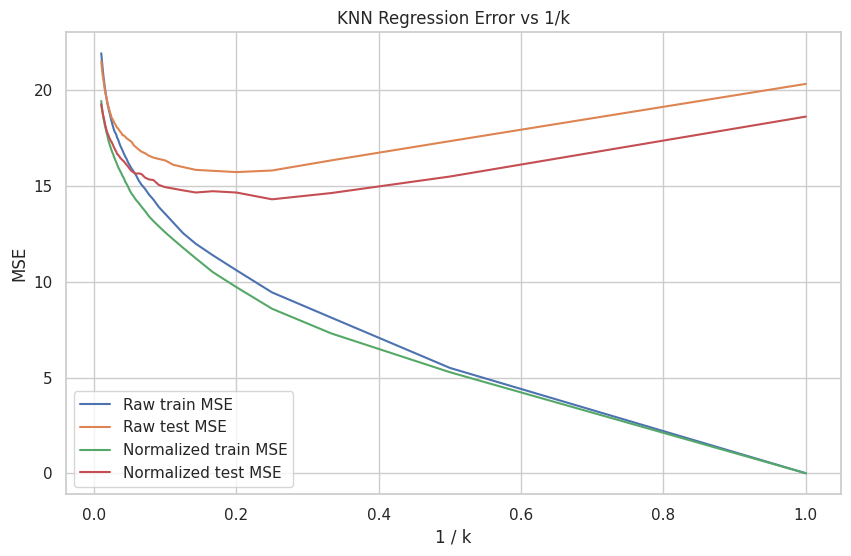

,Features,Best k,Best test MSE
0,Raw,5,15.7268
1,Normalized,4,14.3057



Conclusion:
- For the raw predictors, the best value is k = 5 with a test MSE of 15.7268.
- For the normalized predictors, the best value is k = 4 with a test MSE of 14.3057.
- Normalizing the predictors improves KNN performance because KNN is based on distances and the predictors are measured on different scales.
- Therefore, the normalized KNN model performs better than the raw-feature KNN model on this test set.



In [ ]:
# KNN regression on the same 70/30 split used in part (h).
from sklearn.neighbors import NearestNeighbors

X_train = train_df[predictors].to_numpy()
y_train = train_df[response].to_numpy()
X_test = test_df[predictors].to_numpy()
y_test = test_df[response].to_numpy()
ks = np.arange(1, 101)

# Standardization is important for KNN because KNN is distance-based.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Efficiently find the 100 nearest neighbors once, then use cumulative means
# to obtain predictions for every k = 1,...,100.
def knn_mse_curves(Xtr, ytr, Xte, yte, max_k=100):
    nn = NearestNeighbors(n_neighbors=max_k)
    nn.fit(Xtr)
    train_idx = nn.kneighbors(Xtr, return_distance=False)
    test_idx = nn.kneighbors(Xte, return_distance=False)
    train_neighbor_y = ytr[train_idx]
    test_neighbor_y = ytr[test_idx]
    train_cum = np.cumsum(train_neighbor_y, axis=1)
    test_cum = np.cumsum(test_neighbor_y, axis=1)
    train_mse, test_mse = [], []
    for k in range(1, max_k + 1):
        train_pred = train_cum[:, k-1] / k
        test_pred = test_cum[:, k-1] / k
        train_mse.append(mean_squared_error(ytr, train_pred))
        test_mse.append(mean_squared_error(yte, test_pred))
    return train_mse, test_mse

raw_train_mse, raw_test_mse = knn_mse_curves(X_train, y_train, X_test, y_test)
norm_train_mse, norm_test_mse = knn_mse_curves(X_train_scaled, y_train, X_test_scaled, y_test)

best_raw_k = int(ks[np.argmin(raw_test_mse)])
best_norm_k = int(ks[np.argmin(norm_test_mse)])
print(f'Best raw-feature k: {best_raw_k}, test MSE = {min(raw_test_mse):.4f}')
print(f'Best normalized-feature k: {best_norm_k}, test MSE = {min(norm_test_mse):.4f}')

x_axis = 1 / ks
plt.figure(figsize=(10, 6))
plt.plot(x_axis, raw_train_mse, label='Raw train MSE')
plt.plot(x_axis, raw_test_mse, label='Raw test MSE')
plt.plot(x_axis, norm_train_mse, label='Normalized train MSE')
plt.plot(x_axis, norm_test_mse, label='Normalized test MSE')
plt.xlabel('1 / k'); plt.ylabel('MSE'); plt.title('KNN Regression Error vs 1/k')
plt.legend(); plt.show()

knn_summary = pd.DataFrame({
    'Features': ['Raw', 'Normalized'],
    'Best k': [best_raw_k, best_norm_k],
    'Best test MSE': [min(raw_test_mse), min(norm_test_mse)]
})
display(knn_summary)

print("""
Conclusion:
- For the raw predictors, the best value is k = 5 with a test MSE of 15.7268.
- For the normalized predictors, the best value is k = 4 with a test MSE of 14.3057.
- Normalizing the predictors improves KNN performance because KNN is based on distances and the predictors are measured on different scales.
- Therefore, the normalized KNN model performs better than the raw-feature KNN model on this test set.
""")


### (j ) Compare KNN and Linear

In [ ]:
# Compare the best KNN result against the linear-regression models from part (h).
best_knn_type = 'Normalized KNN' if min(norm_test_mse) <= min(raw_test_mse) else 'Raw KNN'
best_knn_test = min(min(norm_test_mse), min(raw_test_mse))

linear_candidates = {
    'All-predictor linear': base_test_mse,
    'Selected quadratic + interaction': improved_test_mse
}
best_linear_name = min(linear_candidates, key=linear_candidates.get)
best_linear_test = linear_candidates[best_linear_name]

final_comparison = pd.DataFrame({
    'Model': [best_linear_name, best_knn_type],
    'Test MSE': [best_linear_test, best_knn_test]
}).set_index('Model')
display(final_comparison)

if best_knn_test < best_linear_test:
    print(f'{best_knn_type} has the smaller test MSE on this split.')
else:
    print(f'{best_linear_name} has the smaller test MSE on this split.')

print("""
Conclusion:
- The selected quadratic + interaction regression model has a test MSE of 18.6600.
- The normalized KNN model has a lower test MSE of 14.3057.
- Therefore, normalized KNN provides better predictive performance on this particular test split.
- KNN is flexible because it predicts PE using nearby observations, while the regression model represents PE with an explicit equation.
- This comparison is fair because both models were evaluated using the same held-out 30% test set.
""")


,Test MSE
Model,
Selected quadratic + interaction,18.6600
Normalized KNN,14.3057


Normalized KNN has the smaller test MSE on this split.

Conclusion:
- The selected quadratic + interaction regression model has a test MSE of 18.6600.
- The normalized KNN model has a lower test MSE of 14.3057.
- Therefore, normalized KNN provides better predictive performance on this particular test split.
- KNN is flexible because it predicts PE using nearby observations, while the regression model represents PE with an explicit equation.
- This comparison is fair because both models were evaluated using the same held-out 30% test set.



## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

In [ ]:
answer = """Better. With a very large n and small p, a flexible method has enough observations to estimate a more complicated relationship with less danger of overfitting. Its lower bias can therefore improve performance."""
print(answer)


Better. With a very large n and small p, a flexible method has enough observations to estimate a more complicated relationship with less danger of overfitting. Its lower bias can therefore improve performance.


### (b) The number of predictors p is extremely large, and the number of observations n is small.

In [ ]:
answer = """Worse. When p is extremely large but n is small, a flexible method can fit random noise and have high variance. An inflexible method is generally safer because it is less likely to overfit."""
print(answer)


Worse. When p is extremely large but n is small, a flexible method can fit random noise and have high variance. An inflexible method is generally safer because it is less likely to overfit.


### (c) The relationship between the predictors and response is highly non-linear.

In [ ]:
answer = """Better. A highly non-linear relationship is difficult for an inflexible method to represent. A flexible method can adapt to the curvature and usually has lower bias in this situation."""
print(answer)


Better. A highly non-linear relationship is difficult for an inflexible method to represent. A flexible method can adapt to the curvature and usually has lower bias in this situation.


### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

In [ ]:
answer = """Worse. If the error variance is extremely high, much of the observed variation is noise. A flexible method may chase that noise, increasing variance and hurting test performance."""
print(answer)


Worse. If the error variance is extremely high, much of the observed variation is noise. A flexible method may chase that noise, increasing variance and hurting test performance.


## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [ ]:
# Correct Euclidean distance is sqrt(sum of squared coordinate differences).
knn_class_data['Distance to (0,0,0)'] = np.sqrt(
    ((knn_class_data[['X1', 'X2', 'X3']].to_numpy() - test_point)**2).sum(axis=1)
)

display(knn_class_data)

print('Distances: 3, 2, sqrt(10), sqrt(5), sqrt(2), sqrt(3).')


,Observation,X1,X2,X3,Y,"Distance to (0,0,0)"
0,1,0,3,0,Red,3.0000
1,2,2,0,0,Red,2.0000
2,3,0,1,3,Red,3.1623
3,4,0,1,2,Green,2.2361
4,5,-1,0,1,Green,1.4142
5,6,1,1,1,Red,1.7321


Distances: 3, 2, sqrt(10), sqrt(5), sqrt(2), sqrt(3).


### (b) What is our prediction with K = 1? Why?

In [ ]:
nearest = knn_class_data.sort_values('Distance to (0,0,0)').iloc[0]
print(f"K = 1 prediction: {nearest['Y']}")
print(f"Reason: Observation {int(nearest['Observation'])} is the closest point, with distance {nearest['Distance to (0,0,0)']:.3f}, and its class is {nearest['Y']}.")


K = 1 prediction: Green
Reason: Observation 5 is the closest point, with distance 1.414, and its class is Green.


### (c) What is our prediction with K = 3? Why?

In [ ]:
three_nearest = knn_class_data.sort_values('Distance to (0,0,0)').head(3)
display(three_nearest[['Observation', 'Y', 'Distance to (0,0,0)']])
prediction_k3 = three_nearest['Y'].mode().iloc[0]
print(f'K = 3 prediction: {prediction_k3}')
print('Reason: the three nearest observations are 5 (Green), 6 (Red), and 2 (Red), so Red wins by a 2-to-1 majority.')


,Observation,Y,"Distance to (0,0,0)"
4,5,Green,1.4142
5,6,Red,1.7321
1,2,Red,2.0000


K = 3 prediction: Red
Reason: the three nearest observations are 5 (Green), 6 (Red), and 2 (Red), so Red wins by a 2-to-1 majority.


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

In [ ]:
answer = """Small K. A small K gives KNN a more flexible, local decision boundary. A large K averages over many points and produces a smoother, less flexible boundary, which can miss a highly non-linear Bayes boundary."""
print(answer)


Small K. A small K gives KNN a more flexible, local decision boundary. A large K averages over many points and produces a smoother, less flexible boundary, which can miss a highly non-linear Bayes boundary.
